In [8]:
# PV Inversion

In [169]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.cm import get_cmap
import metpy.calc as mpcalc
from metpy.units import units
from numpy import *
import xarray as xr
from netCDF4 import Dataset, num2date
import math
import pygrib
import cdsapi
from datetime import datetime, timedelta
from geopy.distance import geodesic
import numpy as np

In [170]:
# Replicating Figures from GitHub (vorticity globally, corresponding streamfunction values)

import sys
import xarray as xr

# Constant
level = 500

#sys.path.append('/gdex/data/d633000/e5.oper.an.pl/202601/e5.oper.an.pl.128_060_pv.ll025sc.2026013100_2026013123.nc')
# Relative vorticity
file_rv_2_1 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_138_vo.ll025sc.2026020100_2026020123.nc'
file_pv_1_31 =  '/gdex/data/d633000/e5.oper.an.pl/202601/e5.oper.an.pl.128_060_pv.ll025sc.2026013100_2026013123.nc'

fileuwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_131_u.ll025uv.2026020100_2026020123.nc' # /gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_131_u.ll025uv.2026020100_2026020123.nc
filevwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_132_v.ll025uv.2026020100_2026020123.nc' # /gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_132_v.ll025uv.2026020100_2026020123.nc

ds  = xr.open_dataset(file_rv_2_1)
du = xr.open_dataset(fileuwnd)
print(du)
dv = xr.open_dataset(filevwnd)
vor = ds.VO

ds = ds.VO.metpy.sel(level=level)
vor2d = ds.isel(time=0)

<xarray.Dataset> Size: 4GB
Dimensions:            (time: 24, level: 37, latitude: 721, longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 192B 2026-02-01 ... 2026-02-01T2...
  * level              (level) float64 296B 1.0 2.0 3.0 ... 950.0 975.0 1e+03
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    U                  (time, level, latitude, longitude) float32 4GB ...
    quantization_info  |S1 1B ...
    utc_date           (time) int32 96B ...
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.9.2
    CONVERSION_PLATFORM:  Linux crhtc68 6.4.0-150600.23.81-default #1 SMP PRE...
    CONVERSION_DATE:      Tue May  5 10:15:35 AM MDT 2026
    Conventions:          CF-1.6
    NETCDF_COMPRESSION

In [171]:
from xinvert import invert_Poisson

iParams = {
    'BCs'      : ['extend', 'periodic'],
    'mxLoop'   : 1000,
    'tolerance': 1e-12,
}

sf = invert_Poisson(vor2d, dims=['latitude','longitude'], iParams=iParams)

{} loops 1000 and tolerance is 2.769307e-04


In [172]:
#import proplot as pplt
import xarray as xr
import numpy as np

# select the first time step
u = du.U.sel(time='2026-02-01T00:00:00.000000000', level=500).load() # u = du.U.where(du.U!=0)[0].load()
v = dv.V.sel(time='2026-02-01T00:00:00.000000000', level=500).load() # v = dv.V.where(dv.V!=0)[0].load()
print(du.time[0])

m = np.hypot(u, v)

print(u.shape)
print(v.shape)
print(sf.shape)

<xarray.DataArray 'time' ()> Size: 8B
array('2026-02-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2026-02-01
Attributes:
    long_name:  time
(721, 1440)
(721, 1440)
(721, 1440)


In [7]:
# PLOTTING
fig, axes = pplt.subplots(nrows=2, ncols=1, figsize=(7, 7), sharex=3, sharey=3,
                          proj=pplt.Proj('cyl', lon_0=180))

fontsize = 13

axes.format(abc='(a)', coast=True,
            lonlines=60, latlines=30, lonlabels='b', latlabels='l',
            grid=False, labels=False)

ax = axes[0]
p = ax.contourf(u.lon, u.lat, vor[0]*1e5, cmap='bwr',
                levels=np.linspace(-10, 10, 22))
ax.set_title('relative vorticity', fontsize=fontsize)
ax.colorbar(p, loc='r', label='', ticks=2, length=0.98)

ax = axes[1]
p = ax.contourf(u.lon, u.lat, sf[0], levels=30, cmap='jet')
ax.quiver(u.lon.values, u.lat.values, u.values, v.values,
              width=0.0007, headwidth=12., headlength=15.)
              # headwidth=1, headlength=3, width=0.002)
ax.set_title('wind field and inverted streamfunction', fontsize=fontsize)
ax.colorbar(p, loc='r', label='', length=0.98)


NameError: name 'pplt' is not defined

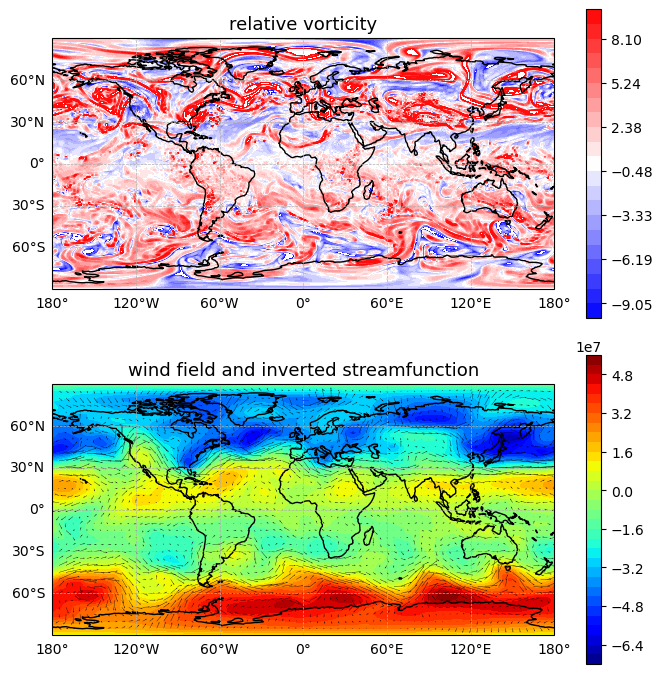

In [173]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

fontsize = 13

for ax in axes:
    ax.coastlines()
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False

# Relative vorticity

cf1 = axes[0].contourf(
    u.longitude,
    u.latitude,
    vor2d * 1e5,         
    levels=np.linspace(-10, 10, 22),
    cmap='bwr',
    transform=ccrs.PlateCarree()
)

axes[0].set_title(
    'relative vorticity',
    fontsize=fontsize
)

plt.colorbar(
    cf1,
    ax=axes[0],
    orientation='vertical'
)

# Streamfunction

cf2 = axes[1].contourf(
    u.longitude,
    u.latitude,
    sf,               
    levels=30,
    cmap='jet',
    transform=ccrs.PlateCarree()
)

skip = 20

axes[1].quiver(
    u.longitude.values[::skip],
    u.latitude.values[::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    width=0.0007
)

axes[1].set_title(
    'wind field and inverted streamfunction',
    fontsize=fontsize
)

plt.colorbar(
    cf2,
    ax=axes[1],
    orientation='vertical'
)

plt.tight_layout()
plt.show()

In [139]:
from metpy.calc import lat_lon_grid_deltas
from metpy.calc import first_derivative
from metpy.calc import divergence
from metpy.calc import vorticity
from metpy.units import units
from scipy.ndimage import gaussian_filter

In [107]:
# Isolating rotational wind
sf = sf.sortby('latitude')
psi = sf.values * units('m^2/s')
dx, dy = lat_lon_grid_deltas(sf.longitude.values,sf.latitude.values) # Do I need to account for Earth geometry? Or is Cartesian grid fine?
sf_vals = sf.values
#print(sf_vals)
#print(sf.dims)

# Taking derivatives
u_component = -first_derivative(psi, delta=dy,axis=0) # axis zero for latitude (north-south : j hat)
v_component = first_derivative(psi, delta=dx, axis=1) # axis one for longitude (east-west: i hat) # sf_vals instead of psi

# Putting back into array with lat and lon
u_rot = xr.DataArray(u_component, coords=sf.coords, dims=sf.dims) 
#u_rot = u_rot * units('m/s')
v_rot = xr.DataArray(v_component, coords=sf.coords, dims=sf.dims) 
#v_rot = v_rot * units('m/s')

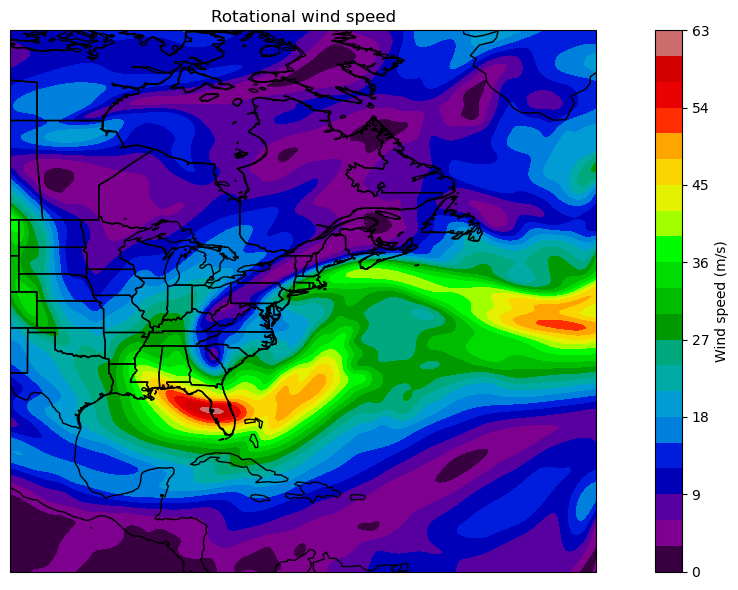

"\n# Skip some vectors\nskip = 30\n\nfig, ax = plt.subplots(figsize=(12,6), subplot_kw={'projection': ccrs.PlateCarree()})\nax.contourf(sf.longitude, sf.latitude, vor2d * 1e5, levels=21, cmap='bwr')\nax.quiver(\n    sf.longitude[::skip],\n    sf.latitude[::skip],\n    u_rot.values[::skip, ::skip],\n    v_rot.values[::skip, ::skip],\n    scale=300\n)\nax.coastlines()\nax.set_title('Rotational wind + vorticity')\n"

In [166]:
# Wind speed calc - plot as shading
fig, ax = plt.subplots(figsize=(12,6), subplot_kw={'projection': ccrs.PlateCarree()})

speed = np.sqrt(u_rot.values**2 + v_rot.values**2)
speed_smooth = gaussian_filter(speed, sigma=2)

cf = ax.contourf(
    sf.longitude,
    sf.latitude,
    speed_smooth,
    levels=21,
    cmap='nipy_spectral'
)
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="#bdbdbd")
ax.add_feature(cfeature.STATES.with_scale('50m')) # , linewidth=0.5,  edgecolor='gray')
plt.colorbar(cf, ax=ax, label='Wind speed (m/s)')
ax.set_title('Rotational wind speed')
ax.set_extent([-105, -40, 10, 70], ccrs.PlateCarree())
plt.tight_layout()
plt.show()

'''
# Skip some vectors
skip = 30

fig, ax = plt.subplots(figsize=(12,6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.contourf(sf.longitude, sf.latitude, vor2d * 1e5, levels=21, cmap='bwr')
ax.quiver(
    sf.longitude[::skip],
    sf.latitude[::skip],
    u_rot.values[::skip, ::skip],
    v_rot.values[::skip, ::skip],
    scale=300
)
ax.coastlines()
ax.set_title('Rotational wind + vorticity')
'''

In [ ]:
# --- Step 1: Apply consistency condition to isolate TPV vorticity ---

# Use your dynamic centroid box
lat_pv_val = float(lat_pv)
lon_pv_val = float(lon_pv)
dlat = 5
dlon = 5

# Build TPV mask on vor2d grid
tpv_mask = (
    (vor2d.latitude  >= lat_pv_val - dlat) &
    (vor2d.latitude  <= lat_pv_val + dlat) &
    (vor2d.longitude >= lon_pv_val - dlon) &
    (vor2d.longitude <= lon_pv_val + dlon)
)

# Keep only vorticity inside TPV box, zero outside
zeta_tpv = vor2d.where(tpv_mask, other=0.0)

# --- Step 2: Enforce consistency condition ---
tpv_sum  = float(zeta_tpv.sum())
n_outside = int((~tpv_mask).sum())

# Distribute residual uniformly outside box
compensation = -tpv_sum / n_outside
zeta_balanced = zeta_tpv.where(tpv_mask, other=compensation)

# Verify
print(f"Sum before: {float(zeta_tpv.sum()):.4e}")
print(f"Sum after:  {float(zeta_balanced.sum()):.4e}")  # should be ~0

# --- Step 3: Invert balanced vorticity ---
iParams = {
    'BCs'      : ['extend', 'periodic'],
    'mxLoop'   : 1000,
    'tolerance': 1e-12,
}
sf_tpv = invert_Poisson(zeta_balanced, dims=['latitude', 'longitude'], iParams=iParams)

# --- Step 4: Get TPV rotational wind ---
sf_tpv = sf_tpv.sortby('latitude')
psi_tpv = sf_tpv.values * units('m^2/s')
dx, dy = lat_lon_grid_deltas(sf_tpv.longitude.values, sf_tpv.latitude.values)

u_tpv_comp = -first_derivative(psi_tpv, delta=dy, axis=0)
v_tpv_comp =  first_derivative(psi_tpv, delta=dx, axis=1)

u_tpv = xr.DataArray(u_tpv_comp, coords=sf_tpv.coords, dims=sf_tpv.dims)
v_tpv = xr.DataArray(v_tpv_comp, coords=sf_tpv.coords, dims=sf_tpv.dims)

# --- Step 5: Compare TPV wind to total wind at AR centroid ---
lat_idx = np.argmin(np.abs(sf_tpv.latitude.values  - float(lat_vt)))
lon_idx = np.argmin(np.abs(sf_tpv.longitude.values - float(lon_vt)))

speed_tpv   = np.sqrt(float(u_tpv.values[lat_idx, lon_idx])**2 +
                      float(v_tpv.values[lat_idx, lon_idx])**2)
speed_total = np.sqrt(float(u.values[lat_idx, lon_idx])**2 +
                      float(v.values[lat_idx, lon_idx])**2)

ratio = speed_tpv / speed_total
print(f"TPV wind at AR centroid:    {speed_tpv:.2f} m/s")
print(f"Total wind at AR centroid:  {speed_total:.2f} m/s")
print(f"Ratio:                      {ratio:.3f}")

# --- Step 6: Plot side by side for sanity check ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

speed_rot = np.sqrt(u_rot.values**2 + v_rot.values**2)
speed_tpv_field = np.sqrt(u_tpv.values**2 + v_tpv.values**2)

for ax in axes:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='#bdbdbd')
    ax.add_feature(cfeature.STATES.with_scale('50m'))
    ax.set_extent([-105, -40, 10, 70], ccrs.PlateCarree())

cf1 = axes[0].contourf(sf.longitude,     sf.latitude,
                        speed_rot,         levels=21, cmap='nipy_spectral')
axes[0].set_title('Full rotational wind speed')
plt.colorbar(cf1, ax=axes[0], label='m/s')

cf2 = axes[1].contourf(sf_tpv.longitude, sf_tpv.latitude,
                        speed_tpv_field,  levels=21, cmap='nipy_spectral')
axes[1].set_title('TPV-only wind speed')
plt.colorbar(cf2, ax=axes[1], label='m/s')

cf3 = axes[2].contourf(sf_tpv.longitude, sf_tpv.latitude,
                        speed_tpv_field / (speed_rot + 1e-10),
                        levels=np.linspace(0, 1, 21), cmap='RdYlGn')
axes[2].set_title('TPV fraction of rotational wind')
plt.colorbar(cf3, ax=axes[2], label='ratio')

# Mark AR centroid
for ax in axes:
    ax.scatter(float(lon_vt), float(lat_vt),
               marker='*', s=200, color='black',
               transform=ccrs.PlateCarree(), zorder=10,
               label='AR centroid')
    ax.legend(fontsize=8)

plt.suptitle('PV Inversion — TPV Wind Isolation', fontsize=13)
plt.tight_layout()
plt.show()

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


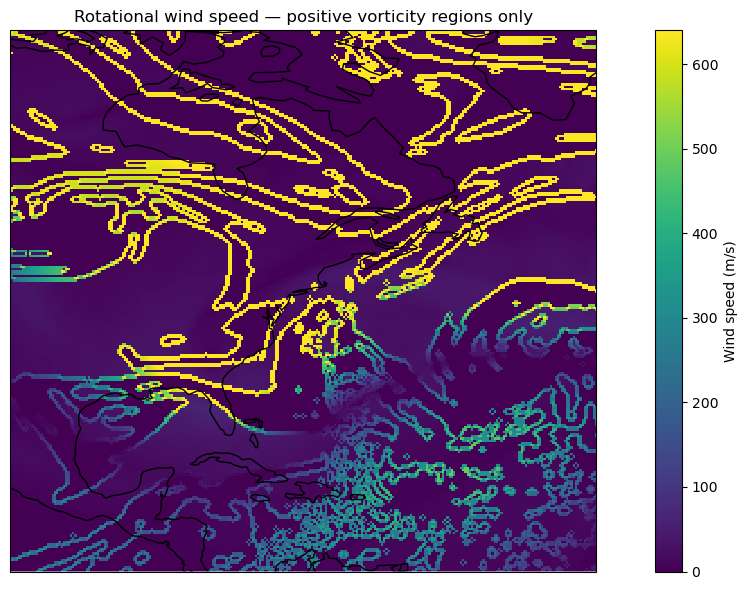

In [168]:
# ONLY positive pv

# Match vor2d to sf's coordinates
vor2d_matched = vor2d.sel(latitude=sf.latitude,longitude=sf.longitude)

# Grab values
psi_tpv = psi.magnitude.copy()
psi_tpv[vor2d.values < 0] = 0

# Recompute rotational wind
u_tpv = -first_derivative(psi_tpv, delta=dy, axis=0)
v_tpv =  first_derivative(psi_tpv, delta=dx, axis=1)

speed_tpv = np.sqrt(u_tpv**2 + v_tpv**2)

# Plot
fig, ax = plt.subplots(figsize=(12,6), subplot_kw={'projection': ccrs.PlateCarree()})
cf = ax.pcolormesh(
    sf.longitude,
    sf.latitude,
    speed_tpv.magnitude,
    #cmap='viridis',
    vmin=0,
    vmax=np.nanpercentile(speed_tpv.magnitude, 95),  # ignore top 5% outliers
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.set_extent([-105, -40, 10, 70], ccrs.PlateCarree())
plt.colorbar(cf, ax=ax, label='Wind speed (m/s)')
ax.set_title('Rotational wind speed — positive vorticity regions only')
plt.tight_layout()
plt.show()

In [146]:
import pandas as pd

# Flatten everything
lats = sf.latitude.values
lons = sf.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

df = pd.DataFrame({
    'lat': lat2d.flatten(),
    'lon': lon2d.flatten(),
    'speed': speed.flatten()
})

print(df.nlargest(10, 'speed'))

       lat    lon      speed
2933 -89.5  13.25  72.484633
2932 -89.5  13.00  72.484615
2931 -89.5  12.75  72.484158
2934 -89.5  13.50  72.484140
2930 -89.5  12.50  72.483419
2935 -89.5  13.75  72.483213
2929 -89.5  12.25  72.482504
2936 -89.5  14.00  72.482270
2928 -89.5  12.00  72.481334
2937 -89.5  14.25  72.481292


In [158]:
print("Max speed location:")
max_idx = np.unravel_index(np.nanargmax(speed_tpv.magnitude), speed_tpv.magnitude.shape)
print(f"  speed: {speed_tpv.magnitude[max_idx]:.1f} m/s")
print(f"  lat: {sf.latitude.values[max_idx[0]]:.2f}")
print(f"  lon: {sf.longitude.values[max_idx[1]]:.2f}")

# What does the mask boundary look like there?
print(f"  vor2d: {vor2d_matched.values[max_idx]:.4e}")  # should be right near zero

Max speed location:
  speed: 21049.7 m/s
  lat: -89.50
  lon: 126.25
  vor2d: -3.2300e-05


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


vor2d     std: 4.6995e-05
vor_check2 std: 1.3948e-02


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


"\ndifference = z_check.magnitude - original_vor\nprint(difference)\n\nplt.figure(figsize=(10,4))\nplt.contourf(\n    sf.longitude,\n    sf.latitude,\n    original_vor,\n    cmap='bwr',\n    levels= 21 # np.linspace(-10, 10, 22),   # transform=ccrs.PlateCarree()\n)\nplt.colorbar()\nplt.title('Recovered vorticity minus original vorticity')\n"

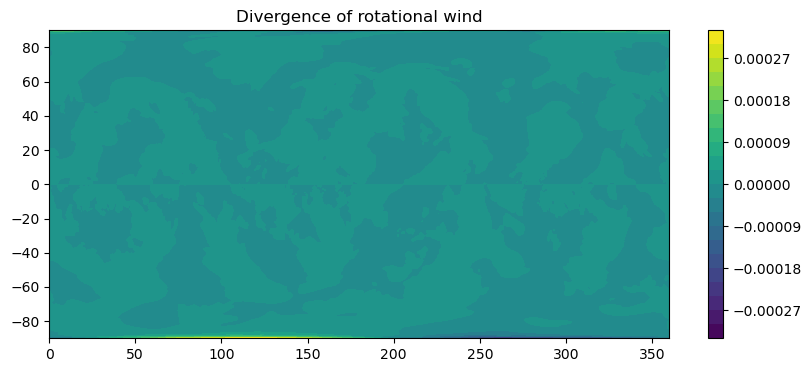

In [115]:
# CHECK

# Take u, v, put into metpy divergence and plotting divergence should get zeros or very close to zero
div = divergence(u_rot.values,v_rot.values,dx=dx,dy=dy)

plt.figure(figsize=(10,4))
plt.contourf(
    sf.longitude,
    sf.latitude,
    div,
    levels=21
)
plt.colorbar()
plt.title('Divergence of rotational wind')


# Or can calculate vorticity from u and v and it should be exactly the same as the relative vorticity plot

# z_check = vorticity(u_rot.values, v_rot.values, dx=dx, dy=dy)
vor_check2 = vorticity(u_rot, v_rot)
print("vor2d     std: {:.4e}".format(np.nanstd(vor2d.values)))
print("vor_check2 std: {:.4e}".format(np.nanstd(vor_check2)))

dvdx = first_derivative(v_component,delta=dx,axis=1)
dudy = first_derivative(u_component,delta=dy,axis=0)
vor_check = dvdx - dudy


'''
dvdx = first_derivative(
    v_rot.values,
    delta=dx,
    axis=1
)

dudy = first_derivative(
    u_rot.values,
    delta=dy,
    axis=0
)

z_check = dvdx - dudy
original_vor = ds.isel(time=0)
'''
'''
difference = z_check.magnitude - original_vor
print(difference)

plt.figure(figsize=(10,4))
plt.contourf(
    sf.longitude,
    sf.latitude,
    original_vor,
    cmap='bwr',
    levels= 21 # np.linspace(-10, 10, 22),   # transform=ccrs.PlateCarree()
)
plt.colorbar()
plt.title('Recovered vorticity minus original vorticity')
'''

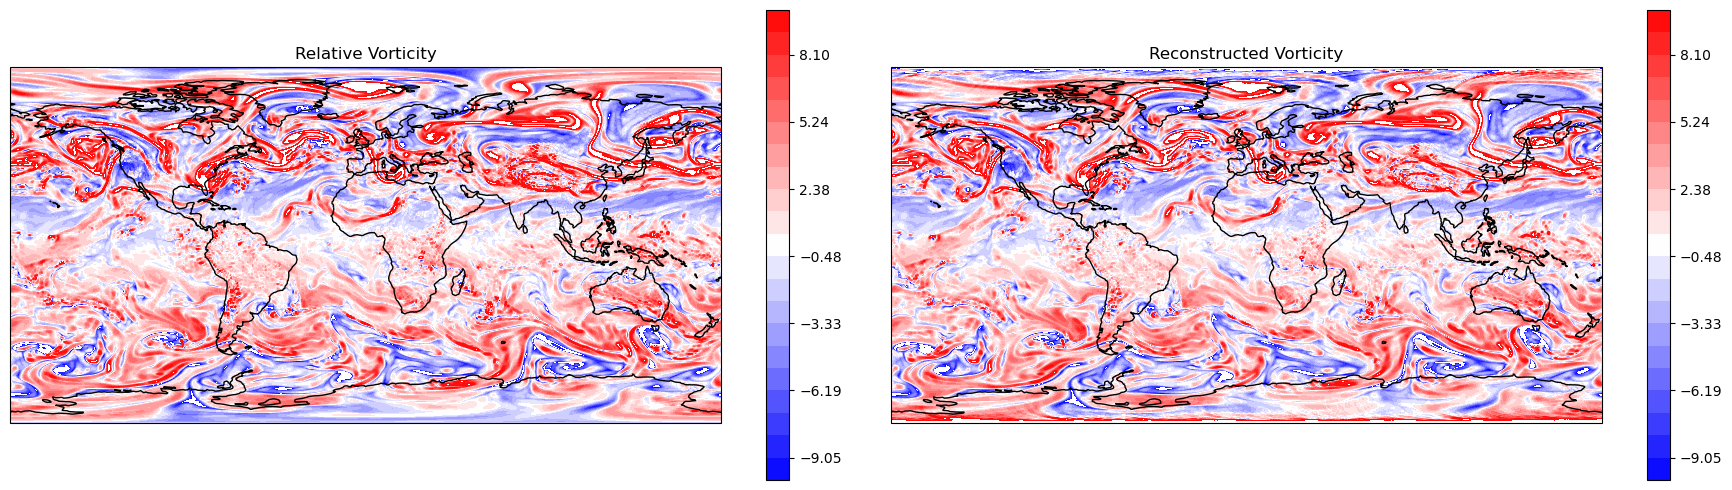

In [125]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18,5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

levels = np.linspace(-10, 10, 22)

cf1 = axes[0].contourf(
    vor2d.longitude,
    vor2d.latitude,
    vor2d * 1e5,
    levels=levels,
    cmap='bwr',
)

axes[0].coastlines()
axes[0].set_title('Relative Vorticity')

cf2 = axes[1].contourf(
    sf.longitude,
    sf.latitude,
    vor_check2 * 1e5,
    levels=levels,
    cmap='bwr'
)

axes[1].coastlines()
axes[1].set_title('Reconstructed Vorticity')

plt.colorbar(cf1, ax=axes[0])
plt.colorbar(cf2, ax=axes[1])

plt.tight_layout()
plt.show()

In [109]:
# Trim n points from each boundary
n = 3  # adjust as needed

interior = np.zeros(vor2d.shape, dtype=bool)
interior[n:-n, n:-n] = True  # True = interior points only

vor_true = vor2d.values.flatten()
vor_recon = vor_check.magnitude.flatten()

mask = interior.flatten() & np.isfinite(vor_true) & np.isfinite(vor_recon)

v_true = vor_true[mask]
v_recon = vor_recon[mask]

from scipy import stats

# --- Bias (mean error) ---
bias = np.mean(v_recon - v_true)

# --- RMSE ---
rmse = np.sqrt(np.mean((v_recon - v_true)**2))

# --- Pearson correlation ---
r, p_val = stats.pearsonr(v_true, v_recon)

# --- Max absolute error ---
max_err = np.max(np.abs(v_recon - v_true))

# --- Relative RMSE (normalized by std of true field) ---
rmse_rel = rmse / np.std(v_true)

print(f"Bias:          {bias:.4e}")
print(f"RMSE:          {rmse:.4e}")
print(f"Relative RMSE: {rmse_rel:.4f}  (0 = perfect, 1 = error ~ signal size)")
print(f"Pearson r:     {r:.6f}  (p = {p_val:.2e})")
print(f"Max abs error: {max_err:.4e}")

Bias:          4.8063e-07
RMSE:          7.1462e-05
Relative RMSE: 1.5185  (0 = perfect, 1 = error ~ signal size)
Pearson r:     0.004400  (p = 8.36e-06)
Max abs error: 7.4472e-04


[[        nan         nan         nan ...         nan         nan
          nan]
 [ 0.29265471  0.292675    0.29266369 ...  0.29273041  0.29275014
   0.29277114]
 [ 0.00242626  0.0024355   0.00242778 ...  0.0022345   0.00228605
   0.00233756]
 ...
 [-0.00188701 -0.00199576 -0.00203258 ... -0.00192922 -0.00205912
  -0.00220167]
 [-0.24178588 -0.24184613 -0.24191556 ... -0.24178331 -0.24184791
  -0.24190622]
 [        nan         nan         nan ...         nan         nan
          nan]]


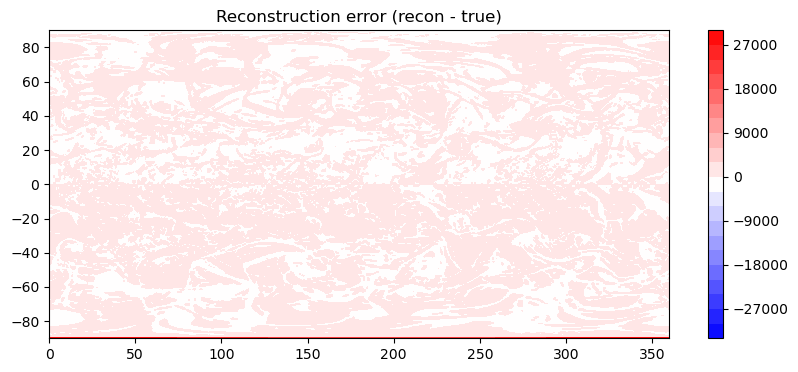

In [129]:
error = vor_check2.values - vor2d.values

plt.figure(figsize=(10,4))
plt.contourf(sf.longitude, sf.latitude, error * 1e5, levels=21, cmap='bwr')
plt.colorbar()
plt.title('Reconstruction error (recon - true)')
print(error)

In [113]:
print("vor2d    — mean: {:.4e}  std: {:.4e}".format(
    np.nanmean(vor2d.values), np.nanstd(vor2d.values)))
print("vor_check — mean: {:.4e}  std: {:.4e}".format(
    np.nanmean(vor_check.magnitude), np.nanstd(vor_check.magnitude)))

vor2d    — mean: -5.3632e-07  std: 4.6995e-05
vor_check — mean: 8.2381e-10  std: 1.1311e-04
